In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import numpy as np
import time
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


In [2]:
path = "Telco_customer_churn.xlsx"
print(path)
print(os.listdir("."))
df = pd.read_excel(path)

Telco_customer_churn.xlsx
['.vscode', 'ensemble_cv_scores.csv', 'ensemble_repeated_cv_ci.csv', 'ensemble_test_scores.csv', 'ensemble_threshold_comparison.csv', 'telcoemble.ipynb', 'Telco_customer_churn.xlsx']


In [3]:
print(df.head)

<bound method NDFrame.head of       CustomerID  Count        Country       State          City  Zip Code  \
0     3668-QPYBK      1  United States  California   Los Angeles     90003   
1     9237-HQITU      1  United States  California   Los Angeles     90005   
2     9305-CDSKC      1  United States  California   Los Angeles     90006   
3     7892-POOKP      1  United States  California   Los Angeles     90010   
4     0280-XJGEX      1  United States  California   Los Angeles     90015   
...          ...    ...            ...         ...           ...       ...   
7038  2569-WGERO      1  United States  California       Landers     92285   
7039  6840-RESVB      1  United States  California      Adelanto     92301   
7040  2234-XADUH      1  United States  California         Amboy     92304   
7041  4801-JZAZL      1  United States  California  Angelus Oaks     92305   
7042  3186-AJIEK      1  United States  California  Apple Valley     92308   

                    Lat Long   La

In [4]:
print(df.columns.tolist())

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [5]:
# Convert TotalCharges to numeric
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# Fill missing values
df = df.fillna(df.median(numeric_only=True))

In [6]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:

drop_cols = [
    'CustomerID', 'Customer ID', 'Count', 'Country', 'State', 'City', 'Zip Code',
    'Lat Long', 'Latitude', 'Longitude',
    'Churn Label', 'Churn Score', 'Churn Reason'
 ]
df = df.drop(drop_cols, axis=1, errors='ignore')


drop_prefixes = (
    'CustomerID_', 'Customer ID_',
    'Churn Label_', 'Churn Reason_', 'Churn Score_'
)
encoded_leakage_cols = [c for c in df.columns if c.startswith(drop_prefixes)]
df = df.drop(columns=encoded_leakage_cols, errors='ignore')

In [8]:
y = df['Churn Value']
X = df.drop('Churn Value', axis=1)


In [9]:
remaining_customer_cols_df = [c for c in df.columns if 'CustomerID' in c or 'Customer ID' in c]
remaining_customer_cols_X = [c for c in X.columns if 'CustomerID' in c or 'Customer ID' in c]
print('Remaining customer-related columns in df:', remaining_customer_cols_df)
print('Remaining customer-related columns in X:', remaining_customer_cols_X)

Remaining customer-related columns in df: []
Remaining customer-related columns in X: []


In [10]:
print(df.columns.tolist())
print(X.columns.tolist())

['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV', 'City_Acton', 'City_Adelanto', 'City_Adin', 'City_Agoura Hills', 'City_Aguanga', 'City_Ahwahnee', 'City_Alameda', 'City_Alamo', 'City_Albany', 'City_Albion', 'City_Alderpoint', 'City_Alhambra', 'City_Aliso Viejo', 'City_Alleghany', 'City_Alpaugh', 'City_Alpine', 'City_Alta', 'City_Altadena', 'City_Alturas', 'City_Alviso', 'City_Amador City', 'City_Amboy', 'City_Anaheim', 'City_Anderson', 'City_Angels Camp', 'City_Angelus Oaks', 'City_Angwin', 'City_Annapolis', 'City_Antelope', 'City_Antioch', 'City_Anza', 'City_Apple Valley', 'City_Applegate', 'City_Aptos', 'City_Arbuckle', 'City_Arcadia', 'City_Arcata', 'City_Armona', 'City_Arnold', 'City_Aromas', 'City_Arroyo Grande', 'City_Artesia', 'City_Arvin', 'City_Atascadero', 'City_Atherton', 'City_Atwater', 'City_Auberry', 'City_Auburn', 'City_Avalon', 'City_Avenal', 'City_Avery', 'City_Avila Beach', 'City_Azusa', 'City_Badger', 'City_Baker', 'City_Bakersfield', 'Cit

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
models = {
    "lr": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, solver='lbfgs')),
    "rf": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "xgb": XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        n_estimators=200,
        verbosity=1
    ),
    "mlp": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42, verbose=True)
}

trained_models = {}
total = len(models)

for i, (name, model) in enumerate(models.items(), start=1):
    print(f"[{i}/{total}] Training '{name}'...", flush=True)
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    trained_models[name] = model
    print(f"[{i}/{total}] Finished '{name}' in {elapsed:.2f}s", flush=True)

print("All models trained.")

[1/4] Training 'lr'...
[1/4] Finished 'lr' in 1.41s
[2/4] Training 'rf'...
[2/4] Finished 'rf' in 1.10s
[3/4] Training 'xgb'...
[3/4] Finished 'xgb' in 5.17s
[4/4] Training 'mlp'...
Iteration 1, loss = 8.42690917
Iteration 2, loss = 1.56682563
Iteration 3, loss = 0.58255028
Iteration 4, loss = 0.68076443
Iteration 5, loss = 0.85122156
Iteration 6, loss = 0.53825258
Iteration 7, loss = 0.65230349
Iteration 8, loss = 0.57247358
Iteration 9, loss = 0.49762792
Iteration 10, loss = 0.59073646
Iteration 11, loss = 0.65782719
Iteration 12, loss = 0.80290042
Iteration 13, loss = 0.70440214
Iteration 14, loss = 0.67417512
Iteration 15, loss = 0.59423825
Iteration 16, loss = 0.61109406
Iteration 17, loss = 0.48374505
Iteration 18, loss = 0.42430275
Iteration 19, loss = 0.43117258
Iteration 20, loss = 0.75585663
Iteration 21, loss = 0.70363699
Iteration 22, loss = 0.47200316
Iteration 23, loss = 0.53519405
Iteration 24, loss = 0.42651655
Iteration 25, loss = 0.60889645
Iteration 26, loss = 0.4172

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    row = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": None
    }

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        row["roc_auc"] = roc_auc_score(y_test, y_prob)

    results.append(row)

scores_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
print(scores_df.to_string(index=False))

model  accuracy  precision   recall       f1  roc_auc
  xgb  0.785664   0.607784 0.542781 0.573446 0.829444
   rf  0.802697   0.677778 0.489305 0.568323 0.849740
  mlp  0.775018   0.643216 0.342246 0.446771 0.827585
   lr  0.716111   0.462428 0.427807 0.444444 0.711692


In [14]:
from sklearn.metrics import accuracy_score, f1_score

print('Train vs Test diagnostics')
diag_rows = []
for name, model in trained_models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    diag_rows.append({
        'model': name,
        'train_acc': accuracy_score(y_train, y_train_pred),
        'test_acc': accuracy_score(y_test, y_test_pred),
        'acc_gap': accuracy_score(y_train, y_train_pred) - accuracy_score(y_test, y_test_pred),
        'train_f1': f1_score(y_train, y_train_pred, zero_division=0),
        'test_f1': f1_score(y_test, y_test_pred, zero_division=0),
        'f1_gap': f1_score(y_train, y_train_pred, zero_division=0) - f1_score(y_test, y_test_pred, zero_division=0)
    })

diag_df = pd.DataFrame(diag_rows).sort_values('test_f1', ascending=False)
print(diag_df.to_string(index=False))

# Simple leakage checks
suspicious_by_name = [c for c in X.columns if any(k in c.lower() for k in [
    'churn', 'label', 'reason', 'score', 'status', 'value'
])]
print('\nSuspicious columns by name (possible leakage):', suspicious_by_name)

corr_with_target = df.corr(numeric_only=True)['Churn Value'].drop('Churn Value', errors='ignore').abs().sort_values(ascending=False)
print('\nTop 15 absolute correlations with target:')
print(corr_with_target.head(15).to_string())

Train vs Test diagnostics
model  train_acc  test_acc  acc_gap  train_f1  test_f1   f1_gap
  xgb   0.982251  0.785664 0.196587  0.966533 0.573446 0.393086
   rf   1.000000  0.802697 0.197303  1.000000 0.568323 0.431677
  mlp   0.884274  0.775018 0.109256  0.734095 0.446771 0.287323
   lr   0.898119  0.716111 0.182008  0.803962 0.444444 0.359517

Suspicious columns by name (possible leakage): []

Top 15 absolute correlations with target:
Tenure Months                            0.352229
Internet Service_Fiber optic             0.308020
Contract_Two year                        0.302253
Payment Method_Electronic check          0.301919
Dependents_Yes                           0.248542
Tech Support_No internet service         0.227890
Device Protection_No internet service    0.227890
Streaming TV_No internet service         0.227890
Streaming Movies_No internet service     0.227890
Internet Service_No                      0.227890
Online Backup_No internet service        0.227890
Online Sec

In [15]:
leak_cols = [c for c in X.columns if c.startswith('Churn Label_') or c.startswith('Churn Reason_') or c.startswith('Churn Score_')]
print('Leakage columns still in X:', leak_cols)
print('Count:', len(leak_cols))

Leakage columns still in X: []
Count: 0


## Ensemble Model Implementation

In [1]:
FAST_MODE = True  
MAX_WORKERS = 2   
CV_FOLDS = 3 if FAST_MODE else 5
CV_REPEATS = 1 if FAST_MODE else 3

print('Runtime config:')
print(f'FAST_MODE={FAST_MODE}, MAX_WORKERS={MAX_WORKERS}, CV_FOLDS={CV_FOLDS}, CV_REPEATS={CV_REPEATS}')

Runtime config:
FAST_MODE=True, MAX_WORKERS=2, CV_FOLDS=3, CV_REPEATS=1


In [2]:
from sklearn.ensemble import VotingClassifier, StackingClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Use runtime config if available
FAST_MODE = globals().get('FAST_MODE', True)
MAX_WORKERS = globals().get('MAX_WORKERS', 2)
CV_FOLDS = globals().get('CV_FOLDS', 3)

def build_base_estimators():
    rf_trees = 120 if FAST_MODE else 300
    xgb_trees = 120 if FAST_MODE else 300
    lr_est = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, solver='lbfgs'))
    rf_est = RandomForestClassifier(n_estimators=rf_trees, random_state=42, n_jobs=MAX_WORKERS)
    xgb_est = XGBClassifier(eval_metric='logloss', random_state=42, n_estimators=xgb_trees, verbosity=0, n_jobs=MAX_WORKERS)
    return lr_est, rf_est, xgb_est

lr_v, rf_v, xgb_v = build_base_estimators()
lr_s, rf_s, xgb_s = build_base_estimators()

voting_soft = VotingClassifier(
    estimators=[('lr', lr_v), ('rf', rf_v), ('xgb', xgb_v)],
    voting='soft',
    n_jobs=MAX_WORKERS
)

voting_hard = VotingClassifier(
    estimators=[('lr', make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, solver='lbfgs'))),
                ('rf', RandomForestClassifier(n_estimators=120 if FAST_MODE else 300, random_state=42, n_jobs=MAX_WORKERS)),
                ('xgb', XGBClassifier(eval_metric='logloss', random_state=42, n_estimators=120 if FAST_MODE else 300, verbosity=0, n_jobs=MAX_WORKERS))],
    voting='hard',
    n_jobs=MAX_WORKERS
)

stacking_model = StackingClassifier(
    estimators=[('lr', lr_s), ('rf', rf_s), ('xgb', xgb_s)],
    final_estimator=LogisticRegression(max_iter=2000),
    cv=CV_FOLDS,
    n_jobs=MAX_WORKERS,
    passthrough=False
)

tree_base = DecisionTreeClassifier(max_depth=6, random_state=42)
bag_trees = 120 if FAST_MODE else 300
try:
    bagging_model = BaggingClassifier(estimator=tree_base, n_estimators=bag_trees, random_state=42, n_jobs=MAX_WORKERS)
except TypeError:
    bagging_model = BaggingClassifier(base_estimator=tree_base, n_estimators=bag_trees, random_state=42, n_jobs=MAX_WORKERS)

adaboost_model = AdaBoostClassifier(n_estimators=120 if FAST_MODE else 300, learning_rate=0.05, random_state=42)

ensemble_models = {
    'voting_soft': voting_soft,
    'voting_hard': voting_hard,
    'stacking': stacking_model,
    'bagging_tree': bagging_model,
    'adaboost': adaboost_model
}

print(f"Ensemble training started (FAST_MODE={FAST_MODE}, workers={MAX_WORKERS})")
ensemble_trained_models = {}
ensemble_train_times = {}
total_ens = len(ensemble_models)

for i, (name, model) in enumerate(ensemble_models.items(), start=1):
    print(f"[{i}/{total_ens}] Training ensemble '{name}'...", flush=True)
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    ensemble_trained_models[name] = model
    ensemble_train_times[name] = elapsed
    print(f"[{i}/{total_ens}] Finished ensemble '{name}' in {elapsed:.2f}s", flush=True)

print('All ensemble models trained.')

NameError: name 'make_pipeline' is not defined

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

MAX_WORKERS = globals().get('MAX_WORKERS', 2)
CV_FOLDS = globals().get('CV_FOLDS', 3)

ensemble_results = []
print('Evaluating ensemble test-set metrics...')
for idx, (name, model) in enumerate(ensemble_trained_models.items(), start=1):
    print(f"  [{idx}/{len(ensemble_trained_models)}] {name}", flush=True)
    y_pred = model.predict(X_test)
    row = {
        'model': name,
        'train_time_sec': ensemble_train_times[name],
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': None
    }
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        row['roc_auc'] = roc_auc_score(y_test, y_prob)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
        row['roc_auc'] = roc_auc_score(y_test, y_score)
    ensemble_results.append(row)

ensemble_scores_df = pd.DataFrame(ensemble_results).sort_values(by='f1', ascending=False)
print('\nEnsemble model test-set performance')
print(ensemble_scores_df.to_string(index=False))

print(f"\nRunning {CV_FOLDS}-fold cross-validation (this may take a while)...")
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
cv_rows = []
for idx, (name, model) in enumerate(ensemble_models.items(), start=1):
    print(f"  [CV {idx}/{len(ensemble_models)}] {name}", flush=True)
    scoring = ['accuracy', 'precision', 'recall', 'f1']
    if hasattr(model, 'predict_proba') or hasattr(model, 'decision_function'):
        scoring.append('roc_auc')

    cv_result = cross_validate(
        model, X_train, y_train, cv=cv, n_jobs=MAX_WORKERS,
        scoring=scoring
    )

    row = {
        'model': name,
        'cv_accuracy_mean': cv_result['test_accuracy'].mean(),
        'cv_f1_mean': cv_result['test_f1'].mean(),
        'cv_roc_auc_mean': cv_result['test_roc_auc'].mean() if 'test_roc_auc' in cv_result else float('nan')
    }
    cv_rows.append(row)

ensemble_cv_df = pd.DataFrame(cv_rows).sort_values(by='cv_f1_mean', ascending=False)
print('\nCross-validation summary')
print(ensemble_cv_df.to_string(index=False))

ensemble_scores_df.to_csv('ensemble_test_scores.csv', index=False)
ensemble_cv_df.to_csv('ensemble_cv_scores.csv', index=False)
print('\nSaved: ensemble_test_scores.csv and ensemble_cv_scores.csv')

Evaluating ensemble test-set metrics...
  [1/5] voting_soft
  [2/5] voting_hard
  [3/5] stacking
  [4/5] bagging_tree
  [5/5] adaboost

Ensemble model test-set performance
       model  train_time_sec  accuracy  precision   recall       f1  roc_auc
bagging_tree       17.724222  0.800568   0.655518 0.524064 0.582467 0.851347
    stacking       22.430871  0.804116   0.671329 0.513369 0.581818 0.850182
 voting_hard        7.920145  0.799148   0.655290 0.513369 0.575712      NaN
 voting_soft       10.844193  0.784244   0.631579 0.449198 0.525000 0.829272
    adaboost       18.127357  0.734564   0.000000 0.000000 0.000000 0.826759

Running 3-fold cross-validation (this may take a while)...
  [CV 1/5] voting_soft
  [CV 2/5] voting_hard
  [CV 3/5] stacking
  [CV 4/5] bagging_tree
  [CV 5/5] adaboost

Cross-validation summary
       model  cv_accuracy_mean  cv_f1_mean  cv_roc_auc_mean
bagging_tree          0.805289    0.582868         0.854604
    stacking          0.807597    0.581775        

In [ ]:
if 'ensemble_ci_df' in globals() and 'f1_mean' in ensemble_ci_df.columns:
    best_ensemble_name = ensemble_ci_df.iloc[0]['model']
else:
    best_ensemble_name = ensemble_cv_df.iloc[0]['model']

best_ensemble = clone(ensemble_models[best_ensemble_name])
print('Best ensemble based on CV F1:', best_ensemble_name)

print('Step 1/2: Threshold tuning on validation split...')
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
best_ensemble.fit(X_subtrain, y_subtrain)

if hasattr(best_ensemble, 'predict_proba'):
    val_score = best_ensemble.predict_proba(X_val)[:, 1]
elif hasattr(best_ensemble, 'decision_function'):
    val_score = best_ensemble.decision_function(X_val)
else:
    val_score = best_ensemble.predict(X_val)

thresholds = np.linspace(0.2, 0.8, 31)
best_t, best_f1 = 0.5, -1
for t in thresholds:
    val_pred_t = (val_score >= t).astype(int)
    f1_t = f1_score(y_val, val_pred_t, zero_division=0)
    if f1_t > best_f1:
        best_f1 = f1_t
        best_t = t

print(f'Best threshold on validation set: {best_t:.3f} (F1={best_f1:.4f})')

print('Step 2/2: Refit and evaluate tuned threshold on test set...')
best_ensemble.fit(X_train, y_train)
if hasattr(best_ensemble, 'predict_proba'):
    test_score = best_ensemble.predict_proba(X_test)[:, 1]
elif hasattr(best_ensemble, 'decision_function'):
    test_score = best_ensemble.decision_function(X_test)
else:
    test_score = best_ensemble.predict(X_test)

test_pred_default = (test_score >= 0.5).astype(int)
test_pred_tuned = (test_score >= best_t).astype(int)

threshold_compare_df = pd.DataFrame([
    {
        'model': best_ensemble_name,
        'setting': 'default_0.50',
        'accuracy': accuracy_score(y_test, test_pred_default),
        'precision': precision_score(y_test, test_pred_default, zero_division=0),
        'recall': recall_score(y_test, test_pred_default, zero_division=0),
        'f1': f1_score(y_test, test_pred_default, zero_division=0)
    },
    {
        'model': best_ensemble_name,
        'setting': f'tuned_{best_t:.3f}',
        'accuracy': accuracy_score(y_test, test_pred_tuned),
        'precision': precision_score(y_test, test_pred_tuned, zero_division=0),
        'recall': recall_score(y_test, test_pred_tuned, zero_division=0),
        'f1': f1_score(y_test, test_pred_tuned, zero_division=0)
    }
])
print('\nThreshold comparison on test set')
print(threshold_compare_df.to_string(index=False))
print('\nClassification report (tuned threshold)')
print(classification_report(y_test, test_pred_tuned, zero_division=0))
print('Confusion matrix (tuned threshold)')
print(confusion_matrix(y_test, test_pred_tuned))

threshold_compare_df.to_csv('ensemble_threshold_comparison.csv', index=False)
print('\nSaved: ensemble_threshold_comparison.csv')

Best ensemble based on CV F1: bagging_tree
Step 1/2: Threshold tuning on validation split...
Best threshold on validation set: 0.380 (F1=0.6646)
Step 2/2: Refit and evaluate tuned threshold on test set...

Threshold comparison on test set
       model      setting  accuracy  precision   recall       f1
bagging_tree default_0.50  0.800568   0.655518 0.524064 0.582467
bagging_tree  tuned_0.380  0.788502   0.582609 0.716578 0.642686

Classification report (tuned threshold)
              precision    recall  f1-score   support

           0       0.89      0.81      0.85      1035
           1       0.58      0.72      0.64       374

    accuracy                           0.79      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.79      0.79      1409

Confusion matrix (tuned threshold)
[[843 192]
 [106 268]]

Saved: ensemble_threshold_comparison.csv


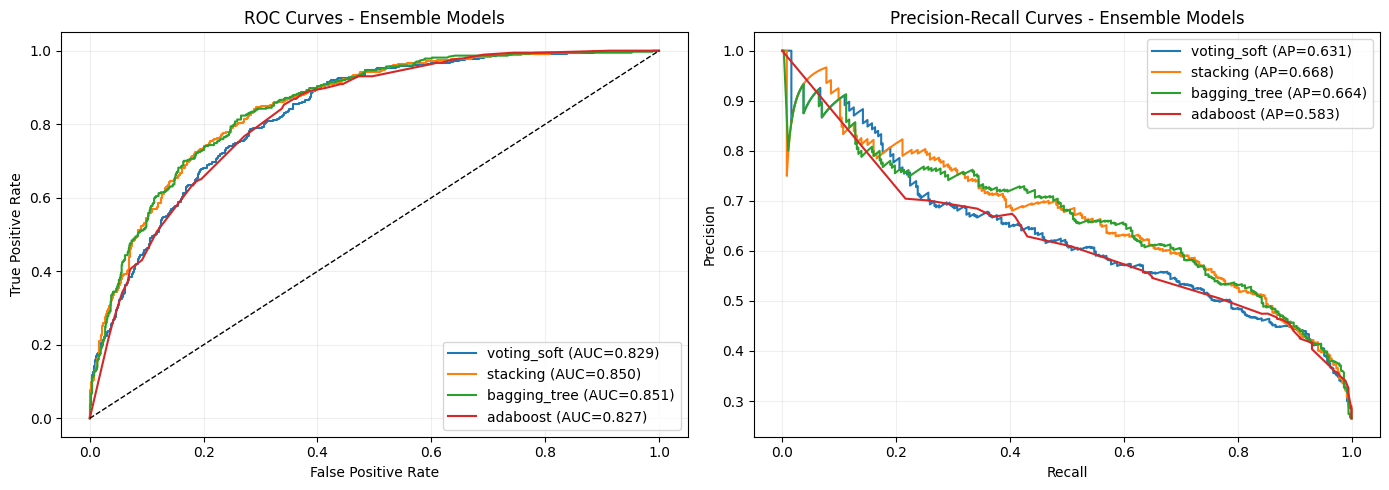

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
for name, model in ensemble_trained_models.items():
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Ensemble Models')
plt.legend()
plt.grid(alpha=0.2)

plt.subplot(1, 2, 2)
for name, model in ensemble_trained_models.items():
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
    else:
        continue
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - Ensemble Models')
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold
import numpy as np

MAX_WORKERS = globals().get('MAX_WORKERS', 2)
CV_FOLDS = globals().get('CV_FOLDS', 3)
CV_REPEATS = globals().get('CV_REPEATS', 1)

print(f'Repeated CV started: folds={CV_FOLDS}, repeats={CV_REPEATS}, workers={MAX_WORKERS}')
rskf = RepeatedStratifiedKFold(n_splits=CV_FOLDS, n_repeats=CV_REPEATS, random_state=42)
ci_rows = []

for idx, (name, model) in enumerate(ensemble_models.items(), start=1):
    print(f"  [RCV {idx}/{len(ensemble_models)}] {name}", flush=True)
    scoring = ['accuracy', 'f1']
    if hasattr(model, 'predict_proba') or hasattr(model, 'decision_function'):
        scoring.append('roc_auc')

    cv_rep = cross_validate(model, X_train, y_train, scoring=scoring, cv=rskf, n_jobs=MAX_WORKERS)
    n = len(cv_rep['test_f1'])

    row = {
        'model': name,
        'f1_mean': cv_rep['test_f1'].mean(),
        'f1_std': cv_rep['test_f1'].std(),
        'f1_ci95_low': cv_rep['test_f1'].mean() - 1.96 * cv_rep['test_f1'].std() / np.sqrt(n),
        'f1_ci95_high': cv_rep['test_f1'].mean() + 1.96 * cv_rep['test_f1'].std() / np.sqrt(n),
        'acc_mean': cv_rep['test_accuracy'].mean(),
        'acc_std': cv_rep['test_accuracy'].std(),
        'roc_auc_mean': cv_rep['test_roc_auc'].mean() if 'test_roc_auc' in cv_rep else float('nan')
    }
    ci_rows.append(row)

ensemble_ci_df = pd.DataFrame(ci_rows).sort_values(by='f1_mean', ascending=False)
print('Repeated CV with 95% confidence intervals')
print(ensemble_ci_df.to_string(index=False))
ensemble_ci_df.to_csv('ensemble_repeated_cv_ci.csv', index=False)
print('\nSaved: ensemble_repeated_cv_ci.csv')

Repeated CV started: folds=3, repeats=1, workers=2
  [RCV 1/5] voting_soft
  [RCV 2/5] voting_hard
  [RCV 3/5] stacking
  [RCV 4/5] bagging_tree
  [RCV 5/5] adaboost
Repeated CV with 95% confidence intervals
       model  f1_mean   f1_std  f1_ci95_low  f1_ci95_high  acc_mean  acc_std  roc_auc_mean
bagging_tree 0.582868 0.022058     0.557907      0.607829  0.805289 0.011741      0.854604
    stacking 0.581775 0.019725     0.559454      0.604097  0.807597 0.008977      0.852921
 voting_hard 0.560012 0.016307     0.541559      0.578466  0.799965 0.008699           NaN
 voting_soft 0.533210 0.006563     0.525784      0.540637  0.789670 0.003135      0.828178
    adaboost 0.000000 0.000000     0.000000      0.000000  0.734647 0.000251      0.837103

Saved: ensemble_repeated_cv_ci.csv
